<a href="https://colab.research.google.com/github/Alone1011/ImageProcessing/blob/main/Pertemuan_5/2311532011_RifkiYuliandra_PengolahanCitra_imageBrightening_IP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

## Defenisikan fungsi Konvulusi

In [6]:
def konvolusi_5x5_manual(citra):
    # Mengambil dimensi citra
    tinggi, lebar, kanal = citra.shape

    # Membuat citra output kosong (berisi nol) dengan ukuran yang sama
    citra_hasil = np.zeros_like(citra, dtype=np.float32)

    # Kernel rataan 5x5 sesuai rumus K = 1/25 * [1,1,1...1]
    # Karena nilainya semua 1, kita cukup menjumlahkan piksel dan membaginya dengan 25
    pembagi = 25.0

    # Menentukan ukuran padding untuk kernel 5x5 (k = 2)
    pad = 2

    # Menambahkan padding 0 di sekeliling citra
    # (padding untuk tinggi dan lebar, tidak ada padding untuk kanal warna)
    citra_pad = np.pad(citra, ((pad, pad), (pad, pad), (0, 0)), mode='constant', constant_values=0)

    # Melakukan iterasi konvolusi
    # Karena instruksi melarang penggunaan library, kita gunakan nested loop murni
    # Loop untuk setiap kanal warna (R, G, B)
    for c in range(kanal):
        # Loop untuk setiap baris piksel
        for i in range(tinggi):
            # Loop untuk setiap kolom piksel
            for j in range(lebar):
                total_nilai = 0.0

                # Mengalikan dengan kernel 5x5 (karena bobotnya 1 semua, kita cukup jumlahkan)
                for u in range(-pad, pad + 1):
                    for v in range(-pad, pad + 1):
                        total_nilai += citra_pad[i + pad + u, j + pad + v, c]

                # Membagi dengan 25 dan menyimpan ke citra hasil
                citra_hasil[i, j, c] = total_nilai / pembagi

    # Memastikan nilai piksel kembali ke rentang 0-255 dan bertipe integer
    citra_hasil = np.clip(citra_hasil, 0, 255).astype(np.uint8)

    return citra_hasil

Penjelasan kode:
1. **Inisialisasi Dimensi & Citra Kosong:** Program pertama-tama membaca dimensi tinggi, lebar, dan jumlah kanal dari citra masukan. Matriks kosong (citra_hasil) dibuat dengan ukuran yang identik untuk menampung hasil perhitungan.
2. **Penerapan Zero Padding:** Untuk menangani masalah ketiadaan nilai piksel saat kernel $5\times5$ memproses area pinggir citra, dilakukan penambahan dua baris dan kolom bernilai nol (zero padding) di sekeliling citra menggunakan fungsi np.pad. Ini merupakan salah satu solusi standar mengatasi border pixel.
3. **Pemrosesan Per Kanal Warna:** Sesuai kaidah konvolusi citra berwarna, dilakukan perulangan (for c in range(kanal)) agar filter diimplementasikan secara terpisah pada setiap komponen warna Merah, Hijau, dan Biru (RGB).
4. **Perulangan Konvolusi Manual (Tanpa Library Instan)**: Pemrosesan menghindari fungsi siap pakai dengan menyusun blok nested loop (perulangan bersarang). Untuk setiap koordinat piksel $(i,j)$, program membuat sub-perulangan $(u,v)$ dengan rentang -2 hingga 2 (mewakili kernel $5\times5$).Kalkulasi Matematika Kernel Rataan: Di dalam sub-perulangan, nilai intensitas dari piksel tetangga dijumlahkan. Karena semua elemen matriks kernel rataan memiliki bobot 1, operasi perkalian matriks disederhanakan menjadi penjumlahan murni. Total hasil penjumlahan tersebut kemudian dibagi dengan total elemen matriks yaitu 25 (pembagi = 25.0). Nilai hasil bagi ini menjadi nilai piksel yang baru di posisi tersebut.
5. **Normalisasi Tipe Data** (np.clip & astype(np.uint8)): Setelah semua proses perhitungan floating point selesai, hasilnya dibatasi agar tetap berada di ambang warna standar (0-255) dan diubah kembali menjadi tipe data unsigned integer 8-bit agar citra dapat ditampilkan secara visual dengan benar.

## 1. Membaca Citra

In [8]:
# Matplotlib membaca citra RGB secara default
nama_file = 'gambar.jpg'
citra_asli = mpimg.imread(nama_file)

# Jika gambar PNG (skala 0-1), ubah ke 0-255
if citra_asli.dtype == np.float32:
    citra_asli = (citra_asli * 255).astype(np.uint8)

print("Proses konvolusi sedang berjalan (mungkin butuh 1-2 menit karena menggunakan loop manual)...")

Proses konvolusi sedang berjalan (mungkin butuh 1-2 menit karena menggunakan loop manual)...


## 2. Menjalankan fungsi konvolusi

In [9]:
citra_smooth = konvolusi_5x5_manual(citra_asli)

print("Konvolusi selesai!")

Konvolusi selesai!


## 3. Visualisasi Hasil

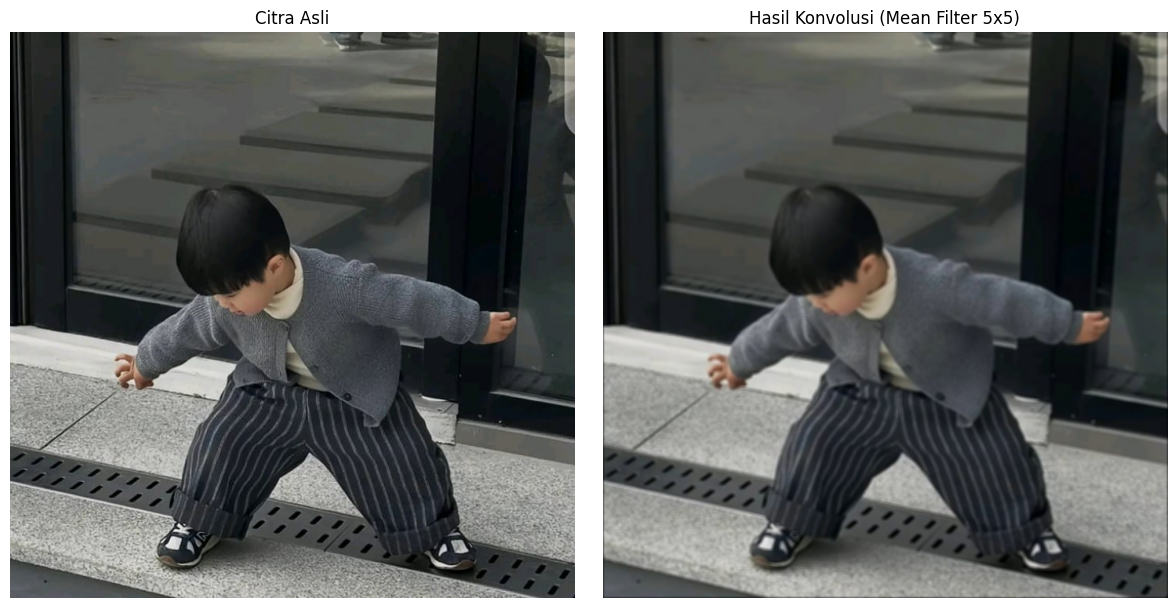

In [10]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(citra_asli)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(citra_smooth)
plt.title('Hasil Konvolusi (Mean Filter 5x5)')
plt.axis('off')

plt.tight_layout()
plt.show()